# Consistency Models Training Example

[![arXiv](https://img.shields.io/badge/arXiv-2301.01469-<COLOR>.svg)](https://arxiv.org/abs/2303.01469) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Kinyugo/consistency_models/blob/main/notebooks/consistency_models_training_example.ipynb) [![GitHub Repo stars](https://img.shields.io/github/stars/Kinyugo/consistency_models?style=social) ](https://github.com/Kinyugo/consistency_models)

## 📖 Introduction

[Consistency Models](https://arxiv.org/abs/2303.01469) are a new family of generative models that achieve high sample quality without adversarial training. They support fast one-step generation by design, while still allowing for few-step sampling to trade compute for sample quality. They also support zero-shot data editing, like image inpainting, colorization, and super-resolution, without requiring explicit training on these tasks.


### Key Idea

_Learn a model that maps any arbitrary point in the latent space to the initial data point, i.e: if points lie on the same probability flow trajectory they are mapped to the same initial data point._

### Contributions

- Single step sampling
- Zero-shot data editing: inpainting, outpainting e.t.c

### Definition

Given a diffusion trajectory $x_{\sigma \in \left[\sigma_{min}, \sigma_{max}\right]}$, we define a consistency function $f : \left(x_{\sigma}, \sigma\right) \rightarrow x_{\sigma_{min}}$.

We can then train a consistency model $f_{\theta}\left(., . \right)$ to approximate the consistency function. A property of the consistency function is that $f : \left(x_{\sigma_{min}}, \sigma_{min} \right) \rightarrow x_{\sigma_{min}}$. To achieve this we parameterize the consistency model using skip connections as in [[2]](#2)

$$
f_{\theta}\left(x_{\sigma}, \sigma \right) = c_{skip}\left(\sigma \right)x_{\sigma} + c_{out}\left(\sigma \right)F_{\theta}\left(x_{\sigma}, \sigma \right)
$$

where $c_{skip}\left(\sigma_{min} \right) = 1$ and $c_{out}\left(\sigma_{min} \right) = 0$ and $F_{\theta}\left(.,.\right)$ is the neural network.

### Algorithms

#### Training

To train the model we follow the following algorithm:

```python
for current_training_step in range(total_training_steps):
    data = data_distribution()

  num_timesteps = timestep_schedule(current_training_step, total_training_steps, initial_timesteps, final_timesteps)
  sigmas = karras_schedule(num_timesteps, sigma_min, sigma_max)
  timesteps = uniform_distribution(batch_size, start=0, end=num_timesteps-1)
  noise = standard_gaussian_noise()

  current_sigmas = sigmas[timesteps]
  next_sigmas = sigmas[timesteps + 1]

  current_noisy_data = data + current_sigmas * noise
  next_noisy_data = data + next_sigmas * noise

  student_model_prediction = (skip_scaling(next_sigmas, sigma_data, sigma_min) * next_noisy_data
                            + output_scaling(next_sigmas, sigma_data, sigma_min) * student_model(next_noisy_data, next_sigmas))

  with no_grad():
      teacher_model_prediction = (skip_scaling(current_sigmas, sigma_data, sigma_min) * current_noisy_data
                                + output_scaling(current_sigmas, sigma_data, sigma_min) * teacher_model(current_noisy_data, next_sigmas))

  loss = distance_metric(student_model_prediction, teacher_model_prediction)

  loss.backward()

  with no_grad():
    current_ema_decay_rate = ema_decay_schedule(current_training_step, initial_ema_decay_rate, initial_timesteps)
    teacher_model_params = current_ema_decay_rate * teacher_model_params + (1 - current_ema_decay_rate) * student_model_params

```

#### Sampling

Starting from an initial random noise $\hat{x}_{\sigma_{max}} \sim \mathcal{N}(0, \sigma_{max}^2I)$, the consistency model can be used to sample a point in a single step: $\hat{x}_{\sigma_{min}} = f_{\theta}(x_{\sigma_{max}}, \sigma_{max})$. For iterative refinement, the following algorithm can be used:

```python
# Generate an initial sample from the initial random noise
sample = (skip_scaling(sigma_max, sigma_data, sigma_min) * x_sigma_max
                + output_scaling(sigma_max, sigma_data, sigma_min) * model(x_sigma_max, sigma_max))
sample = clamp?(sample)

for sigma in sigmas:
    noise = standard_gaussian_noise()
    noisy_sample = sample + square_root(square(sigma) - square(sigma_min)) * noise
    sample = (skip_scaling(sigma, sigma_data, sigma_min) * noisy_sample
                + output_scaling(sigma, sigma_data, sigma_min) * model(noisy_sample, sigma))
    sample = clamp?(sample)
```

where `consistency_model` $= f_{\theta}\left(.,.\right)$,
`clamp?` is a function that optionally clips values to a given range.

### References

<a id="1">[1]</a> Song, Y., Dhariwal, P., Chen, M., &amp; Sutskever, I. (2023, May 31). Consistency models. arXiv.org. https://arxiv.org/abs/2303.01469

<a id="2">[2]</a> Karras, T., Aittala, M., Aila, T., &amp; Laine, S. (2022, October 11). Elucidating the design space of diffusion-based Generative Models. arXiv.org. https://arxiv.org/abs/2206.00364

## 🛠️ Setup


### GPU Check

In [2]:
!nvidia-smi

Mon Mar 23 17:45:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   35C    P0             75W /  300W |    1655MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Packages Installation

> **NOTE:** Restart the runtime if using colab after installing the packages.

In [3]:
#%pip install -q lightning gdown torchmetrics einops torchinfo lpips --no-cache --upgrade
#%pip install -q -e git+https://github.com/Kinyugo/consistency_models.git#egg=consistency_models

In [4]:
%env CUDA_VISIBLE_DEVICES=2

env: CUDA_VISIBLE_DEVICES=2


### Imports

In [5]:
import importlib
import json
import os
import zipfile
import glob
from dataclasses import asdict, dataclass
from typing import Any, Callable, List, Optional, Tuple, Union

import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchinfo import summary
from torchmetrics.image.lpip import LearnedPerceptualImagePatchSimilarity
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

import sys
sys.path.append("../../..")

import consistency_models.ODE.consistency_models_variational as _cm_var
importlib.reload(_cm_var)

from consistency_models.ODE.consistency_models_variational import (
    VariationalConsistencyTraining,
    VariationalConsistencySampling,
    VariationalConsistencyTrainingOutput,
)
from consistency_models.utils import update_ema_model_, ema_decay_rate_schedule


## 🧠  Implementation

#### DataModule

Norm stats (0.3047108663749711, 0.3879814586804132)
torch.Size([4, 15, 128, 128])
torch.Size([4, 15, 128, 128])


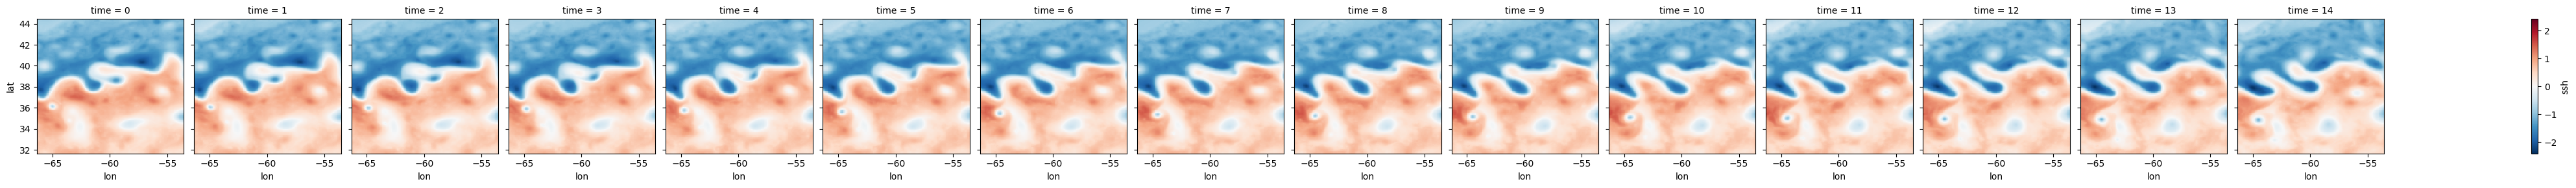

In [6]:
import sys
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
sys.path.append('../../../..')
from src.data_notebook import *

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

import matplotlib.pyplot as plt
import torch
import itertools

lon_min = -66.3 
lon_max = -53.5
lat_min = 31.7
lat_max = 44.5

datadir="/dmidata/users/maxb/NATL_dataset"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")

    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path, obs_from_tgt=False):
    ds =  (
        xr.open_dataset(path)
        # .assign(ssh=lambda ds: ds.ssh.coarsen(lon=2, lat=2).mean().interp(lat=ds.lat, lon=ds.lon))
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )    
    )

    if obs_from_tgt:
        ds = ds.assign(input=ds.tgt.where(np.isfinite(ds.input), np.nan))
    
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

datamodule = BaseDataModule(input_da=load_altimetry_data(datadir+"/natl_gf_w_5nadirs_swot.nc"),
                            domains={'train': {'time': slice('2013-02-24', '2013-09-30',)},
                                     'val': {'time': slice('2012-12-15', '2013-02-24',)},
                                     'test': {'time': slice('2012-10-01', '2012-12-20',)}},
                            xrds_kw={'patch_dims': {'time': 15, 'lat': 128, 'lon': 128},
                                     'strides': {'time': 1, 'lat': 128, 'lon': 128},
                                     'domain_limits':  dict(lon=slice(lon_min, lon_max,),
                                                            lat=slice(lat_min, lat_max,))},
                            dl_kw={'batch_size': 4, 'num_workers': 1},
                            grad=False,
                            #aug_kw={'aug_factor': 1, 'aug_only': True},
                            resize_factor=2)
datamodule.setup()


# datamodule.train_ds[0].input has shape (15, 240, 240)
xr.Dataset(data_vars={'ssh':(('time','lat','lon'),datamodule.train_ds[0].tgt)},
           coords={'time':np.arange(15),
                   'lon':np.arange(lon_min, lon_max, 0.1),
                   'lat':np.arange(lat_min, lat_max, 0.1)}).ssh.plot(col='time',col_wrap=15)

data_loader = datamodule.train_dataloader()
k=10
my_sample = next(itertools.islice(data_loader, k, None))
print(my_sample[0].shape)

### Modules

In [7]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        n_heads: int = 8,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.dropout = dropout

        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)

        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])

        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        noise_level_channels: int,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.input_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels),
            nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, noise_level: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(noise_level)

        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        noise_level_channels: int,
        n_heads: int = 8,
        dropout: float = 0.3,
    ) -> None:
        super().__init__()

        self.unet_block = UNetBlock(
            in_channels, out_channels, noise_level_channels, dropout
        )
        self.self_attention = SelfAttention(
            out_channels, out_channels, n_heads, dropout
        )

    def forward(self, x: Tensor, noise_level: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, noise_level))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()

        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()

        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class NoiseLevelEmbedding(nn.Module):
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()

        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)

        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, x: Tensor) -> Tensor:
        h = x[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)

        return self.projection(h)

### UNet

Our UNet is inspired by Stable Diffusion and Imagen. It's not the same UNet as the paper.

In [8]:

@dataclass
class UNetConfig:
    channels: int = 15            # nb of spatial channels C (SSH time steps)
    time_emb_channels: int = 256  # dimension of the time embedding
    time_emb_scale: float = 16.0
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (128, 128)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (256, 512)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class TimeEmbedding(nn.Module):
    """Fourier-feature embedding for a scalar time in [0, 1]."""
    def __init__(self, channels: int, scale: float = 16.0) -> None:
        super().__init__()
        self.W = nn.Parameter(torch.randn(channels // 2) * scale, requires_grad=False)
        self.projection = nn.Sequential(
            nn.Linear(channels, 4 * channels),
            nn.SiLU(),
            nn.Linear(4 * channels, channels),
            Rearrange("b c -> b c () ()"),
        )

    def forward(self, t: Tensor) -> Tensor:
        h = t[:, None] * self.W[None, :] * 2 * torch.pi
        h = torch.cat([torch.sin(h), torch.cos(h)], dim=-1)
        return self.projection(h)


class UNet(nn.Module):
    """
    Transport-operator network  F_theta  used inside the preconditioned operator:

        g_phi(x, grad_J, t, t') = c_skip(t,t') * x
                                 + c_out(t,t')  * F_theta(c_in(t)*x, grad_J, t, t')

    where  grad_J = nabla_x J(x)  is the spatial gradient of the variational cost
        J(x) = J_o(x, y) + lambda_reg * J_b(x).

    x and grad_J are passed as *separate* arguments (both (B, C, H, W)):
      - input_projection   projects  c_in(t) * x  -> (B, D, H, W)
      - grad_j_projection  projects  grad_J        -> (B, D, H, W)
      their outputs are *added* before the first encoder block.
    This keeps the two signals cleanly decoupled with no channel concatenation
    and no change to the number of input channels relative to a plain UNet.

    Preconditioning scalars (from the interpolant alpha(t), beta(t)):
        c_in(t)       = 1 / ||[alpha(t), beta(t)]||   — normalises x before projection
        c_skip(t, t') = alpha(t') / alpha(t)           — forward-transport ratio
        c_out(t, t')  = beta(t') - c_skip * beta(t)   — residual scale (= coeff of x_0)

    Boundary conditions:
        t' = 0  =>  c_skip = 0,  c_out = 1  =>  g_phi = F_theta(...)  (pure denoiser)
        t' = t  =>  c_skip = 1,  c_out = 0  =>  g_phi = x             (identity)

    Inputs to F_theta:
        x       : (B, C, H, W)  c_in(t) * x_state   — whitened state
        grad_j  : (B, C, H, W)  nabla_x J(x)        — variational gradient (not scaled)
        t       : (B,)           source solver time in [0, 1]
        t_prime : (B,)           target solver time in [0, 1]

    Output:
        (B, C, H, W)  direct prediction of x_0
    """
    def __init__(self, config: UNetConfig) -> None:
        super().__init__()
        self.config = config
        D = config.top_blocks_channels[0]  # inner feature dimension

        # Two separate C -> D projections; their outputs are summed
        self.input_projection = nn.Conv2d(
            config.channels, D, kernel_size=3, padding="same",
        )
        self.grad_j_projection = nn.Conv2d(
            config.channels, D, kernel_size=3, padding="same",
        )
        self.time_embedding = TimeEmbedding(config.time_emb_channels, config.time_emb_scale)

        self.top_encoder_blocks = self._make_encoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            self.config.mid_blocks_channels + self.config.mid_blocks_channels[-1:],
            self.config.mid_blocks_n_blocks_per_resolution,
            self.config.mid_blocks_has_resampling,
            self.config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            self.config.top_blocks_channels + self.config.mid_blocks_channels[:1],
            self.config.top_blocks_n_blocks_per_resolution,
            self.config.top_blocks_has_resampling,
            self.config.top_blocks_dropout,
            self._make_top_block,
        )
        # Output: C channels — direct prediction of x_0
        self.output_projection = nn.Conv2d(D, config.channels, kernel_size=3, padding="same")

    def forward(
        self,
        x: torch.Tensor,       # (B, C, H, W)  c_in(t) * x_state (whitened)
        grad_j: torch.Tensor,  # (B, C, H, W)  nabla_x J(x)      (variational gradient)
        t: torch.Tensor,       # (B,)  source solver time in [0, 1]
        t_prime: torch.Tensor, # (B,)  target solver time in [0, 1]
    ) -> torch.Tensor:         # (B, C, H, W)  F_theta prediction

        # Project x and grad_J independently, then fuse by addition
        h = self.input_projection(x) + self.grad_j_projection(grad_j)  # (B, D, H, W)

        emb_t  = self.time_embedding(t)
        emb_tp = self.time_embedding(t_prime)
        time_emb = torch.cat([emb_t, emb_tp], dim=1)  # (B, 2*time_emb_channels, 1, 1)

        top_encoder_embeddings = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, time_emb)
                top_encoder_embeddings.append(h)
            else:
                h = block(h)

        mid_encoder_embeddings = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, time_emb)
                mid_encoder_embeddings.append(h)
            else:
                h = block(h)

        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_encoder_embeddings.pop()), dim=1)
                h = block(h, time_emb)
            else:
                h = block(h)

        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_encoder_embeddings.pop()), dim=1)
                h = block(h, time_emb)
            else:
                h = block(h)

        return self.output_projection(h)

    # ---- builder helpers ----
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, 2 * self.config.time_emb_channels, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, 2 * self.config.time_emb_channels, self.config.n_heads, dropout
        )

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "UNet":
        with open(os.path.join(pretrained_path, "config.json"), mode="r") as f:
            config_dict = json.load(f)
        config = UNetConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)
        return model


summary(
    UNet(UNetConfig()),
    input_size=((1, 15, 128, 128),   # c_in(t) * x  — whitened state
                (1, 15, 128, 128),   # grad_J        — variational gradient
                (1,),                # t  — source time
                (1,)),               # t' — target time
)


Layer (type:depth-idx)                        Output Shape              Param #
UNet                                          [1, 15, 128, 128]         --
├─Conv2d: 1-1                                 [1, 128, 128, 128]        17,408
├─Conv2d: 1-2                                 [1, 128, 128, 128]        17,408
├─TimeEmbedding: 1-3                          [1, 256, 1, 1]            128
│    └─Sequential: 2-1                        [1, 256, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 1024]                 263,168
│    │    └─SiLU: 3-2                         [1, 1024]                 --
│    │    └─Linear: 3-3                       [1, 256]                  262,400
│    │    └─Rearrange: 3-4                    [1, 256, 1, 1]            --
├─TimeEmbedding: 1-4                          [1, 256, 1, 1]            (recursive)
│    └─Sequential: 2-2                        [1, 256, 1, 1]            (recursive)
│    │    └─Linear: 3-5                       [1, 1024]   

# Observational cost, Prior cost & Regularisation

Les coûts $J_o$ et $J_b$ sont appris conjointement avec l'opérateur de transport $g_\phi$.
Leur gradient $\nabla_x J$ est le **seul** signal temporel passé au réseau — pas de bruit de diffusion.

$$J(x) = \|\mathcal{H}x - y\|^2_{\Sigma_o^{-1}} + \lambda \|x - \Phi(x)\|^2$$


In [9]:
@dataclass
class BaseObsCostConfig:
    w: int=1
    
class BaseObsCost(nn.Module):
    def __init__(self, config: BaseObsCostConfig) -> None:

        super().__init__()
        self.config = config

    def forward(self, state, y):
        # Use zero-filled y and a mask weight so the loss is always differentiable
        # (boolean-index masking can produce an empty tensor → no grad_fn)
        msk = y.isfinite().to(state.dtype)               # float mask, same device/dtype
        y_filled = y.nan_to_num(0.0)
        return self.config.w * (msk * (state - y_filled) ** 2).sum() / (msk.sum() + 1e-8)

    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_obs_cost.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_obs_cost.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "BaseObsCost":
        with open(os.path.join(pretrained_path, "config_obs_cost.json"), mode="r") as f:
            config_dict = json.load(f)
        config = BaseObsCostConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model_obs_cost.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)
        return model
    
@dataclass
class BilinAEPriorCostConfig:
    dim_in: int=15
    dim_hidden: int=64
    kernel_size: int=3
    downsamp: int=None
    bilin_quad: bool=True

class BilinAEPriorCost(nn.Module):
    def __init__(self, config: BilinAEPriorCostConfig) -> None:

        super().__init__()

        self.config = config

        self.conv_in = nn.Conv2d(
            self.config.dim_in, self.config.dim_hidden, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )
        self.conv_hidden = nn.Conv2d(
            self.config.dim_hidden, self.config.dim_hidden, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )

        self.bilin_1 = nn.Conv2d(
            self.config.dim_hidden, self.config.dim_hidden, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )
        self.bilin_21 = nn.Conv2d(
            self.config.dim_hidden, self.config.dim_hidden, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )
        self.bilin_22 = nn.Conv2d(
            self.config.dim_hidden, self.config.dim_hidden, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )

        self.conv_out = nn.Conv2d(
            2 * self.config.dim_hidden, self.config.dim_in, kernel_size=self.config.kernel_size, padding=self.config.kernel_size // 2
        )

        self.down = nn.AvgPool2d(self.config.downsamp) if self.config.downsamp is not None else nn.Identity()
        self.up = (
            nn.UpsamplingBilinear2d(scale_factor=self.config.downsamp)
            if self.config.downsamp is not None
            else nn.Identity()
        )

    def forward_ae(self, x):
        x = self.down(x)
        x = self.conv_in(x)
        x = self.conv_hidden(F.relu(x))

        nonlin = self.bilin_21(x)**2 if self.config.bilin_quad else (self.bilin_21(x) * self.bilin_22(x))
        x = self.conv_out(
            torch.cat([self.bilin_1(x), nonlin], dim=1)
        )
        x = self.up(x)
        return x

    def forward(self, state):
        return F.mse_loss(state, self.forward_ae(state))
    
    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_prior_cost.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_prior_cost.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "BilinAEPriorCost":
        with open(os.path.join(pretrained_path, "config_prior_cost.json"), mode="r") as f:
            config_dict = json.load(f)
        config = BilinAEPriorCostConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model_prior_cost.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)
        return model
    
@dataclass
class DiffusionPriorCostConfig:
    prior_noise: float=0.01

class DiffusionPriorCost(nn.Module):
    def __init__(self, config: DiffusionPriorCostConfig) -> None:

        super().__init__()

        self.config = config

    def forward_step(self, x):
        noise = self.config.prior_noise * torch.randn_like(x)
        x = x + noise
        return x

    def forward(self, state):
        return F.mse_loss(state, self.forward_step(state))
    
    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_prior_cost.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_prior_cost.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "DiffusionPriorCost":
        with open(os.path.join(pretrained_path, "config_prior_cost.json"), mode="r") as f:
            config_dict = json.load(f)
        config = DiffusionPriorCostConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model_prior_cost.pt"), map_location=torch.device("cpu")
        )
        model.load_state_dict(state_dict)
        return model


### LitUNet

In [10]:
@dataclass
class LitConsistencyModelConfig:
    initial_ema_decay_rate: float = 0.95
    teacher_ema_decay_rate: float = 0.99        # fast EMA → stable stop-grad target (T1)
    student_model_ema_decay_rate: float = 0.99993  # slow EMA → inference
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000


class LitConsistencyModel(LightningModule):
    """
    Lightning wrapper for the Variational Pairwise Consistency Model.

    6-term composition-based loss with stochastic trajectory warmup:
      T1 - pairwise consistency via shared x_T  (teacher provides stable stop-grad)
      T2 - composed-path interpolant supervision (progressive denoising)
      T3 - prior regularisation
      T4 - gradient conjugacy constraint
      T5 - descent constraint  max(0, J(x_{t+1}) - J(x_t))
      T6 - stochastic trajectory matching (warmup → decays to 0)

    Three model roles:
      - student_model     : model being optimised (gradients flow through it)
      - teacher_model     : fast EMA of student (decay ~0.99)
                            → used for stop-grad branch of T1 (stable target)
      - ema_student_model : slow EMA of student (decay ~0.99993)
                            → used for inference / sampling only
    """

    def __init__(
        self,
        student_model: nn.Module,
        teacher_model: nn.Module,
        ema_student_model: nn.Module,
        consistency_training: VariationalConsistencyTraining,
        obs_cost,
        prior_cost,
        lambda_reg,
        config: LitConsistencyModelConfig = LitConsistencyModelConfig(),
    ) -> None:
        super().__init__()
        self.consistency_training = consistency_training
        self.student_model = student_model
        self.teacher_model = teacher_model
        self.ema_student_model = ema_student_model
        self.obs_cost = obs_cost
        self.prior_cost = prior_cost
        self.lambda_reg = lambda_reg
        self.config = config
        self.num_timesteps = self.consistency_training.initial_timesteps

        # Teacher and EMA student are inference-only (no gradient)
        for param in self.teacher_model.parameters():
            param.requires_grad = False
        for param in self.ema_student_model.parameters():
            param.requires_grad = False
        self.teacher_model     = self.teacher_model.eval()
        self.ema_student_model = self.ema_student_model.eval()

    def on_train_epoch_start(self) -> None:
        print(f"[Epoch {self.current_epoch}] num_timesteps={self.num_timesteps}")

    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        output: VariationalConsistencyTrainingOutput = self.consistency_training(
            self.student_model,
            self.teacher_model,
            self.obs_cost,
            self.prior_cost,
            self.lambda_reg,
            batch.tgt,
            batch.input,
            self.global_step,
            100000,   # ~2500 epochs × ~40 steps/epoch
        )
        self.num_timesteps = output.num_timesteps

        # Unpack 8 values: total + 6 individual terms + warmup weight
        loss, l_pair, l_interp, l_prior, l_conj, l_desc, l_traj, w_traj = \
            self.consistency_training.compute_loss(output, current_epoch=self.current_epoch)

        if batch_idx == 0:
            t_mean   = output.t_sampled.float().mean().item()
            tp_mean  = output.t_prime_sampled.float().mean().item()
            tpp_mean = output.t_pp_sampled.float().mean().item()
            print(
                f"[Epoch {self.current_epoch} | step {self.global_step}] "
                f"num_ts={output.num_timesteps}  N={len(output.times)}  "
                f"t={t_mean:.3f}  t'={tp_mean:.3f}  t''={tpp_mean:.3f}  "
                f"L_pair={l_pair.item():.4f}  "
                f"L_interp={l_interp.item():.4f}  "
                f"L_prior={l_prior.item():.4f}  "
                f"L_conj={l_conj.item():.4f}  "
                f"L_desc={l_desc.item():.4f}  "
                f"L_traj={l_traj.item():.4f}  "
                f"w_traj={w_traj:.4f}"
            )

        self.log_dict({
            "train_loss":    loss,
            "L_pair":        l_pair,
            "L_interp":      l_interp,
            "L_prior":       l_prior,
            "L_conj":        l_conj,
            "L_desc":        l_desc,
            "L_traj":        l_traj,
            "w_traj":        w_traj,
            "num_timesteps": float(output.num_timesteps),
        })
        return loss

    def on_train_batch_end(self, outputs, batch, batch_idx: int) -> None:
        # Fast EMA update: teacher tracks student closely → stable stop-grad target
        update_ema_model_(self.teacher_model, self.student_model,
                         self.config.teacher_ema_decay_rate)
        # Slow EMA update: used for inference only
        update_ema_model_(self.ema_student_model, self.student_model,
                         self.config.student_model_ema_decay_rate)

    def configure_optimizers(self):
        opt = torch.optim.Adam(
            list(self.student_model.parameters()) +
            list(self.obs_cost.parameters()) +
            list(self.prior_cost.parameters()) +
            [self.lambda_reg],
            lr=self.config.lr,
            betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step"}]

## 🚀 Training

### Training Loop

**Préconditionnement (style Karras, adapté à l'interpolant)** :

| Scalaire | Formule | Rôle |
|----------|---------|------|
| $c_\text{in}(t)$ | $1\,/\,\sqrt{\alpha(t)^2+\beta(t)^2}$ | Normalise la variance de l'entrée réseau |
| $c_\text{skip}(t,t')$ | $\alpha(t')\,/\,\alpha(t)$ | Transport déterministe avant (skip connection) |
| $c_\text{out}(t,t')$ | $\beta(t')-c_\text{skip}\,\beta(t)$ | Échelle du résidu appris par le réseau |

**Conditionnement par $\nabla_x J$** — le gradient spatial du coût variationnel $J(x) = J_o(x,y) + \lambda J_b(x)$ est utilisé comme signal de conditionnement additif, de même shape que $x$.

**Opérateur :**
$$g_\phi(x,\,\nabla_x J,\, t, t') = c_\text{skip}(t,t')\,x + c_\text{out}(t,t')\,F_\theta\!\bigl(c_\text{in}(t)\,x,\; \nabla_x J,\; t,\; t'\bigr)$$

Conditions aux bords garanties : $t'=0 \Rightarrow c_\text{skip}=0,\;c_\text{out}=1$ (débruiteur pur) ; $t'=t \Rightarrow g_\phi=x$ (identité).

---

**Loss $\mathcal{L}$ — 3 termes, teacher/student :**

| # | Terme | Expression | Rôle |
|---|-------|------------|------|
| T1 | **Pairwise consistency** | $\text{nMSE}\bigl(g_s(h_t, t, t''),\; \text{sg}(g_T(h_{t'}, t', t''))\bigr)$ | Cohérence compositionnelle — teacher fournit la cible stable |
| T2 | **Interpolant supervision** | $\tfrac{1}{2}\bigl[\text{nMSE}(g_s(x_T,T,t),\, x_{\text{int},t}) + \text{nMSE}(g_s(x_T,T,t'),\, x_{\text{int},t'})\bigr]$ | Force la variance correcte à chaque pas |
| T3 | **Prior regularisation** | $\|x_0 - \Phi(x_0)\|^2$ | $x_0$ sur le manifold du prior |

où $h_t = g_T(x_T, T, t)$ (teacher, no-grad), $x_{\text{int},t} = \alpha(t)\,x_T + \beta(t)\,x_0$, $\text{sg}$ = stop-gradient, $g_T$ = teacher (EMA rapide ~0.99), $g_s$ = student.

**nMSE (scale-invariant MSE) :**
$$\text{nMSE}(\hat{x},\, x) = \frac{\|\hat{x} - x\|^2}{\text{Var}(x) + \varepsilon}$$

> **Pourquoi nMSE ?** En début d'entraînement le réseau non-initialisé produit des sorties à l'échelle de $\sigma_\text{noise}=80$, ce qui donne un MSE brut $\sim 7\times 10^{16}$. La normalisation par $\text{Var}(\text{cible})$ ramène $L_\text{pair}$ dans $[0, O(1)]$ dès le premier step, quelque soit l'échelle du signal.


In [ ]:

import os
import shutil

def is_valid_checkpoint(path: str) -> bool:
    """Vérifie qu'un checkpoint Lightning est un zip valide (non corrompu)."""
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    """
    Cherche le meilleur checkpoint valide dans ckpt_dir.
    Priorité : last.ckpt, puis checkpoints triés par train_loss croissante.
    """
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt):
        if is_valid_checkpoint(last_ckpt):
            print(f"✅ Checkpoint valide : {last_ckpt}")
            return last_ckpt
        else:
            print("⚠️  last.ckpt corrompu, recherche d'un meilleur checkpoint...")
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Checkpoint valide : {ckpt_path}")
            return ckpt_path
        else:
            print(f"⚠️  Corrompu, ignoré : {ckpt_path}")
    print("❌ Aucun checkpoint valide. Démarrage depuis zéro.")
    return None


@dataclass
class TrainingConfig:
    unet_config: UNetConfig
    consistency_training: VariationalConsistencyTraining
    lit_cm_config: LitConsistencyModelConfig
    trainer: Trainer
    seed: int = 42
    log_dir: str = "logs_variational_consistency"
    log_version: str = "cm"
    resume_ckpt_path: Optional[str] = None
    reload: bool = False
    clean_previous: bool = True   # delete checkpoints & best_model before training

    @property
    def run_dir(self) -> str:
        return os.path.join(self.log_dir, self.log_version)

    @property
    def model_ckpt_path(self) -> str:
        return os.path.join(self.run_dir, "best_model")

    @property
    def lightning_ckpt_dir(self) -> str:
        return os.path.join(self.run_dir, "checkpoints")


def run_training(config: TrainingConfig) -> None:
    seed_everything(config.seed)
    dm = datamodule

    # Clean previous checkpoints and best_model if requested
    if config.clean_previous and not config.reload:
        for dir_to_clean in [config.lightning_ckpt_dir, config.model_ckpt_path]:
            if os.path.exists(dir_to_clean):
                shutil.rmtree(dir_to_clean)
                print(f"🗑️  Cleaned: {dir_to_clean}")
        # Don't resume from a deleted checkpoint
        config.resume_ckpt_path = None

    if not config.reload:
        student_model = UNet(config.unet_config)
    else:
        student_model = UNet.from_pretrained(config.model_ckpt_path)

    # Teacher: fast EMA (~0.99) — provides stable stop-grad targets for T1
    teacher_model = UNet(config.unet_config)
    teacher_model.load_state_dict(student_model.state_dict())

    # EMA student: slow EMA (~0.99993) — used for inference only
    ema_student_model = UNet(config.unet_config)
    ema_student_model.load_state_dict(student_model.state_dict())

    obs_cost   = BaseObsCost(BaseObsCostConfig())
    prior_cost = BilinAEPriorCost(BilinAEPriorCostConfig())
    lambda_reg = nn.Parameter(torch.tensor(1.0))

    lit_cm = LitConsistencyModel(
        student_model,
        teacher_model,
        ema_student_model,
        config.consistency_training,
        obs_cost,
        prior_cost,
        lambda_reg,
        config.lit_cm_config,
    )

    config.trainer.fit(lit_cm, dm, ckpt_path=config.resume_ckpt_path)

    # Sauvegarde du modèle EMA + coûts appris
    lit_cm.ema_student_model.save_pretrained(config.model_ckpt_path)
    lit_cm.obs_cost.save_pretrained(config.model_ckpt_path)
    lit_cm.prior_cost.save_pretrained(config.model_ckpt_path)
    print(f"✅ EMA model saved to: {config.model_ckpt_path}")


### Run Training

In [12]:
# %tensorboard --logdir=logs_CT_full_4DVarNet --port 6006

> **NOTE:** While the paper suggests a final_timesteps value of `150`, it's important to note that during my experimentation on a smaller dataset with approximately 10,000 training steps, I discovered that setting final_timesteps to `17` yielded superior results. This value corresponds to the number of timesteps that would be obtained if we were to train for the same number of steps as mentioned in the paper (600,000 to 1,000,000). However, it's crucial to emphasize that this particular setting has not been extensively explored or experimented with, so it may require further fine-tuning and adjustment to suit your specific needs.

In [ ]:
LOG_DIR     = "logs_PWCM_variational"
LOG_VERSION = "cm"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")
resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

ct = VariationalConsistencyTraining(
    initial_timesteps=5,
    final_timesteps=150,
    sigma_noise=80.0,        # std of x_T = x_0 + sigma_noise * z
    lambda_pair=1.0,        # T1: pairwise consistency via shared x_T
    lambda_interp=1.0,      # T2: composed-path interpolant supervision
    lambda_prior=1.0,       # T3: prior regularisation
    lambda_conj=0.1,        # T4+T5: gradient conjugacy + descent constraint
    lambda_traj=1.0,        # T6: stochastic trajectory matching (warmup)
    warmup_epochs=50,       # number of epochs with full trajectory guidance
    warmup_gamma=0.05,      # exponential decay rate after warmup
)

training_config = TrainingConfig(
    unet_config=UNetConfig(),
    consistency_training=ct,
    lit_cm_config=LitConsistencyModelConfig(lr_scheduler_iters=1000),
    log_dir=LOG_DIR,
    log_version=LOG_VERSION,
    trainer=Trainer(
        accelerator="gpu",
        max_epochs=2500,
        accumulate_grad_batches=4,
        precision="16-mixed",
        log_every_n_steps=1,
        logger=TensorBoardLogger(".", name=LOG_DIR, version=LOG_VERSION),
        callbacks=[
            LearningRateMonitor(logging_interval="step"),
            ModelCheckpoint(
                dirpath=CKPT_DIR,
                monitor="train_loss",
                save_top_k=3,
                save_last=True,
                filename="{epoch:03d}-{step}-{train_loss:.4f}",
            ),
        ],
    ),
    resume_ckpt_path=resume_ckpt,
    clean_previous=True,
)
run_training(training_config)

Using 16bit Automatic Mixed Precision (AMP)
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42


✅ Checkpoint valide : logs_PWCM_variational/cm/checkpoints/epoch=001-step=26-train_loss=0.0836.ckpt


/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/configuration_validator.py:69: UserWarning: You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.
  rank_zero_warn("You passed in a `val_dataloader` but have no `validation_step`. Skipping val loop.")
You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:617: UserWarning: Checkpoint directory logs_PWCM_variational/cm/checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
Restoring sta

Training: 0it [00:00, ?it/s]

[Epoch 2] num_timesteps=5
[Epoch 2 | step 26] num_ts=6  N=6  t=0.480  t'=0.720  t''=0.880  L_pair=0.0020  L_interp=0.0043  L_prior=0.8827  L_conj=0.0000  L_desc=10423.7588  L_traj=0.2763  w_traj=1.0000
[Epoch 2 | step 26] num_ts=6  N=6  t=0.480  t'=0.720  t''=0.880  L_pair=0.0020  L_interp=0.0043  L_prior=0.8827  L_conj=0.0000  L_desc=10423.7588  L_traj=0.2763  w_traj=1.0000
[Epoch 3] num_timesteps=6
[Epoch 3] num_timesteps=6
[Epoch 3 | step 39] num_ts=6  N=6  t=0.520  t'=0.800  t''=0.960  L_pair=0.0016  L_interp=0.0030  L_prior=1.0276  L_conj=0.0000  L_desc=12790.1211  L_traj=0.2887  w_traj=1.0000
[Epoch 3 | step 39] num_ts=6  N=6  t=0.520  t'=0.800  t''=0.960  L_pair=0.0016  L_interp=0.0030  L_prior=1.0276  L_conj=0.0000  L_desc=12790.1211  L_traj=0.2887  w_traj=1.0000
[Epoch 4] num_timesteps=7
[Epoch 4] num_timesteps=7
[Epoch 4 | step 52] num_ts=7  N=7  t=0.479  t'=0.653  t''=0.792  L_pair=0.0030  L_interp=0.0049  L_prior=1.0203  L_conj=0.0000  L_desc=7603.5576  L_traj=0.2676  w_tra

/dmidata/users/maxb/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


✅ EMA model saved to: logs_PWCM_variational/cm/best_model


## 🎲 Sampling & Zero-shot Editing

In [ ]:
seed_everything(42)

Global seed set to 42


42

### Utils

In [16]:
def plot_images(images: Tensor, vmin: float=-2., vmax: float=2., cols: int = 15) -> None:
    xr.Dataset(data_vars={'ssh':(('time','lat','lon'),images.float().cpu())},
           coords={'time':np.arange(images.shape[0]),
                   'lon':np.arange(images.shape[2]),
                   'lat':np.arange(images.shape[1])}).ssh.plot(col='time',col_wrap=cols, 
                                                                  vmin=vmin, vmax=vmax)

### Checkpoint Loading

In [14]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

LOG_DIR     = "logs_PWCM_variational"
LOG_VERSION = "cm"
CKPT_DIR    = os.path.join(LOG_DIR, LOG_VERSION, "checkpoints")

MODEL_PATH = os.path.join(LOG_DIR, LOG_VERSION, "best_model")
unet       = UNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
obs_cost   = BaseObsCost.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
prior_cost = BilinAEPriorCost.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
lambda_reg = nn.Parameter(torch.tensor(1.0, device=device, dtype=dtype), requires_grad=False)


### Load Sample Batch

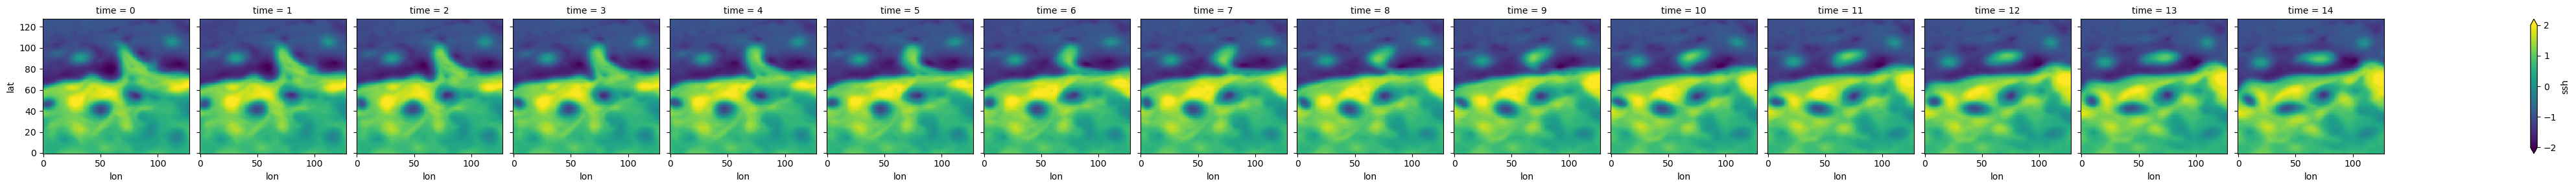

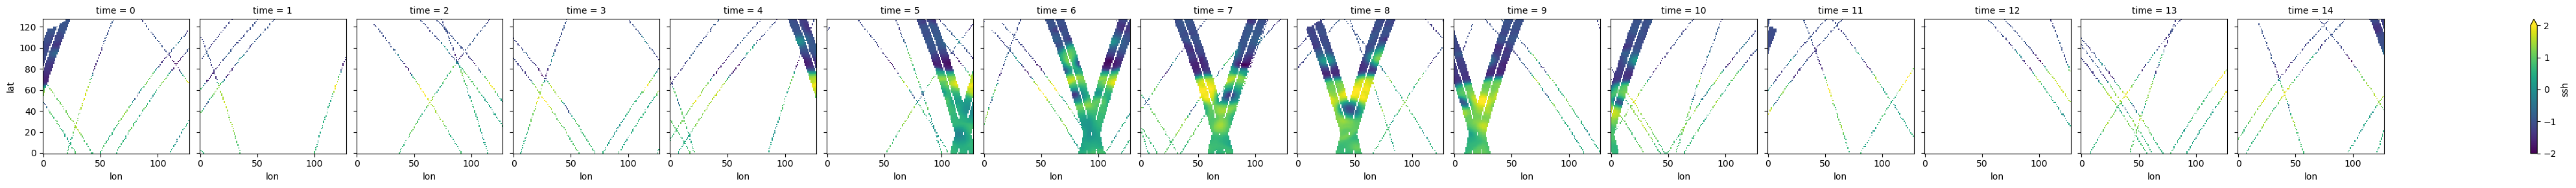

In [17]:
batch = next(iter(datamodule.train_dataloader()))
plot_images(batch.tgt[0])
plot_images(batch.input[0])

### Experiments

#### Sampling

Schedule Karras — 10 steps (T=1 → t=0) :
  step |   t_cur  →  t_next
  -----|--------------------
     0 |  1.0000  →  0.8889
     1 |  0.8889  →  0.7778
     2 |  0.7778  →  0.6667
     3 |  0.6667  →  0.5556
     4 |  0.5556  →  0.4444
     5 |  0.4444  →  0.3333
     6 |  0.3333  →  0.2222
     7 |  0.2222  →  0.1111
     8 |  0.1111  →  0.0000

  t ascendants : [0.0, 0.1111, 0.2222, 0.3333, 0.4444, 0.5556, 0.6667, 0.7778, 0.8889, 1.0]


Variational sampling:   0%|          | 0/9 [00:00<?, ?it/s]

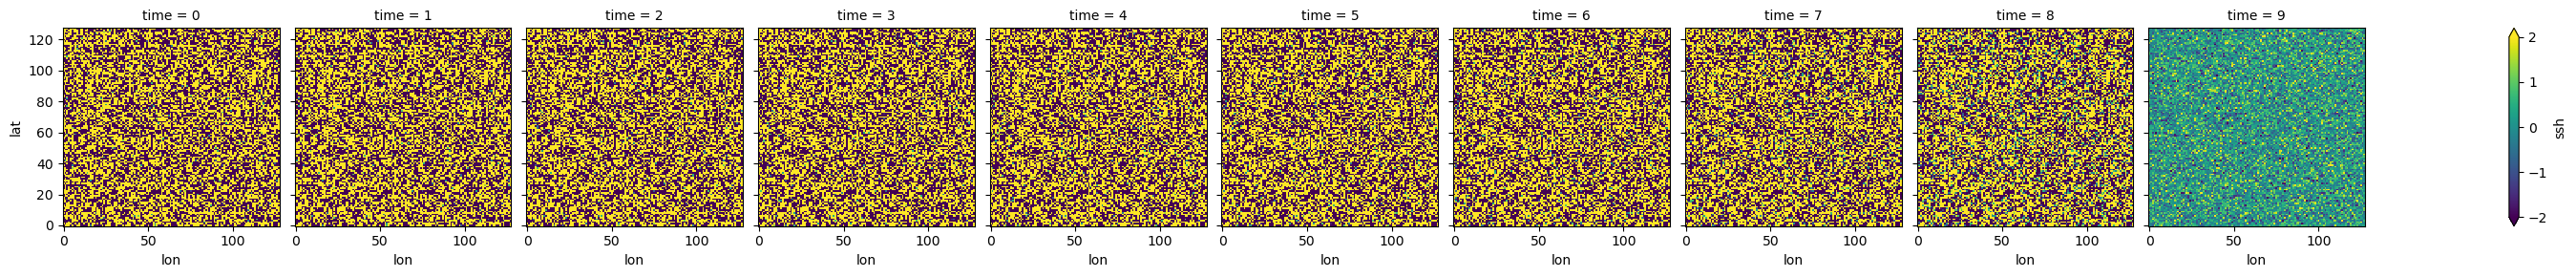

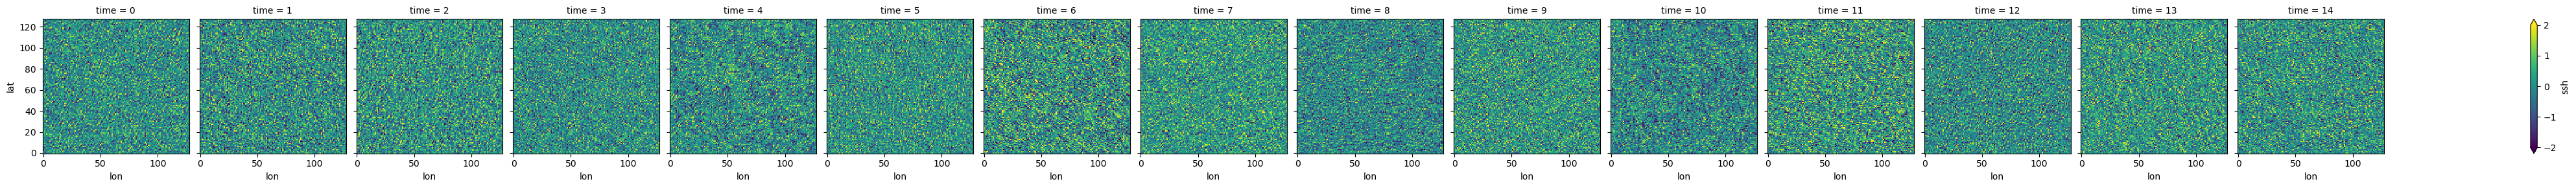

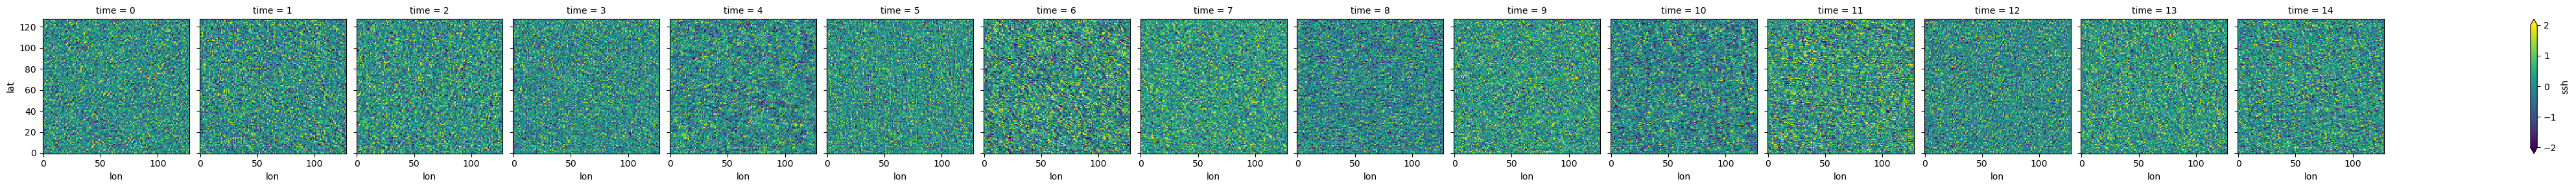

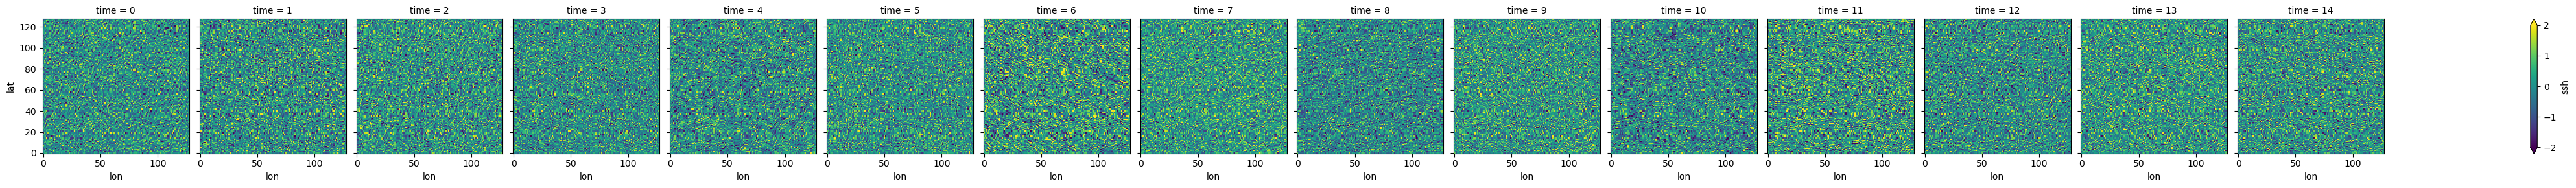

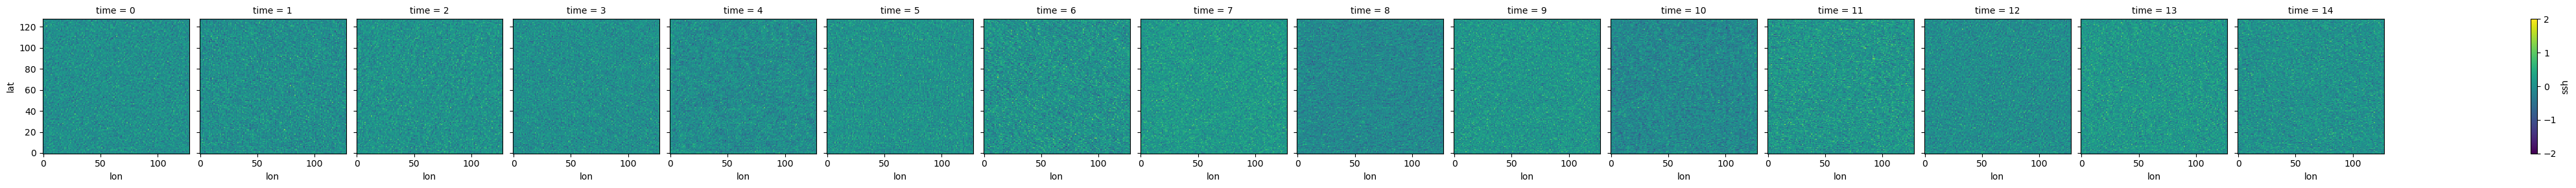

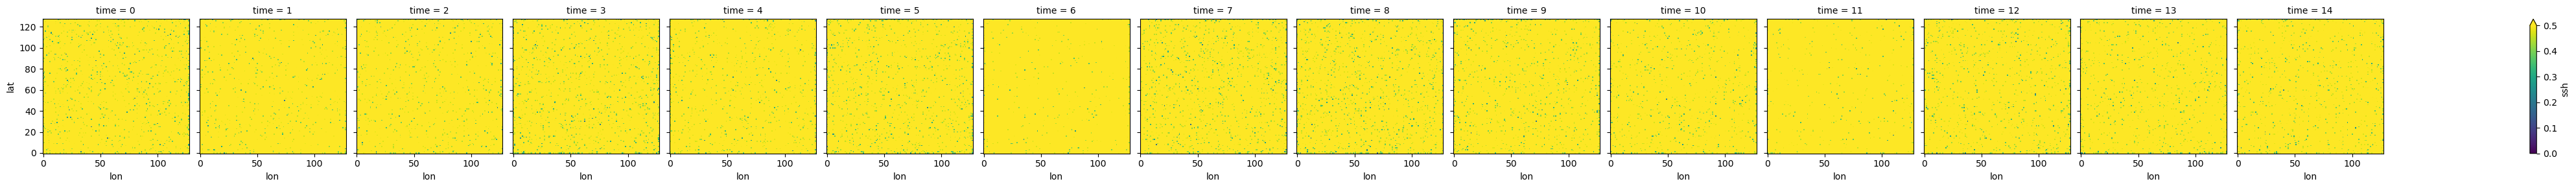

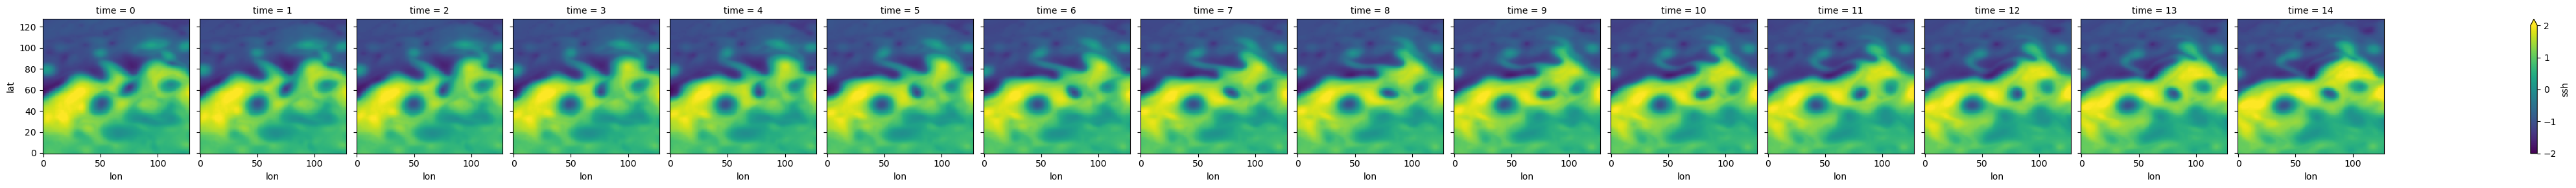

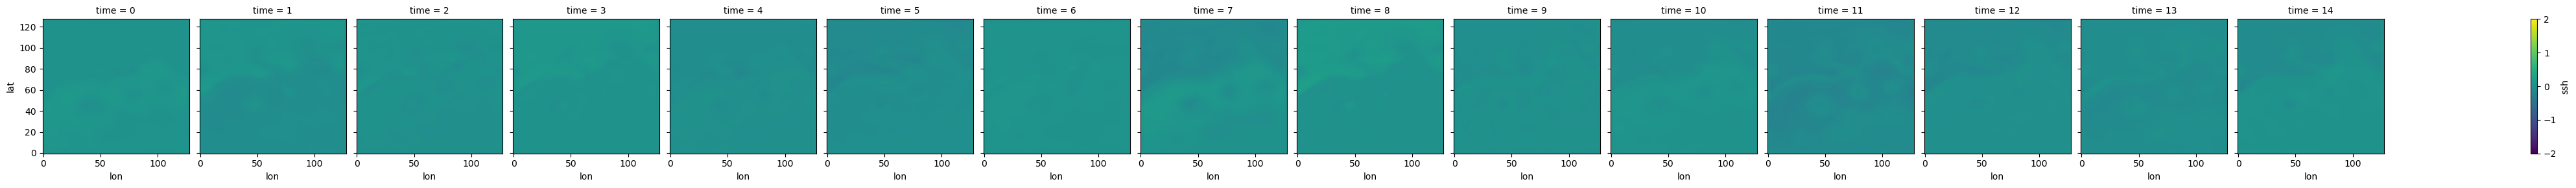

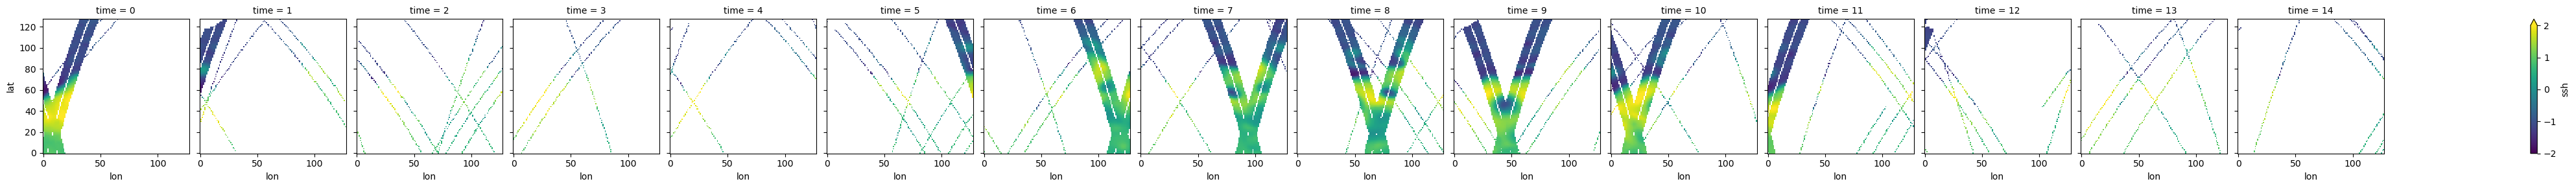

In [18]:
from consistency_models.utils import karras_schedule

NSTEPS = 10

sampler = VariationalConsistencySampling(
    # num_times supprimé du constructeur : passer nsteps au __call__
    sigma_noise=80.0,   # must match training
)

# Affiche les temps de diffusion du schedule Karras utilisé au sampling
_times_asc  = karras_schedule(max(NSTEPS, 3), rho=sampler.rho, device="cpu", as_time=True)
_times_desc = torch.flip(_times_asc, dims=[0])   # ordre d'utilisation : T=1 → 0
print(f"Schedule Karras — {NSTEPS} steps (T=1 → t=0) :")
print("  step |   t_cur  →  t_next")
print("  -----|--------------------")
for step_i, (tc, tn) in enumerate(zip(_times_desc[:-1], _times_desc[1:])):
    print(f"  {step_i:4d} |  {tc.item():.4f}  →  {tn.item():.4f}")
print(f"\n  t ascendants : {[round(v.item(),4) for v in _times_asc]}")

batch = next(iter(datamodule.train_dataloader()))

with torch.no_grad():
    samples = []
    samples_process = []
    for i in range(10):
        sample, sample_process = sampler(
            unet,
            obs_cost,
            prior_cost,
            lambda_reg,
            torch.randn((1, 15, 128, 128), device=device, dtype=dtype),
            batch.input.to(device).to(dtype),
            nsteps=NSTEPS,      # nombre de pas de débruitage (libre au sampling)
            clip_denoised=False,
            verbose=(i == 0),
        )
        samples.append(sample.detach().cpu())
        samples_process.append(sample_process.detach().cpu())

# Visualisation de la trajectoire (sample 0, timestep 7)
plot_images(samples_process[0][:, 0, 7, :, :], cols=10)

# Visualisation des reconstructions individuelles
plot_images(samples[0][0])
plot_images(samples[1][0])
plot_images(samples[2][0])

# Moyenne et dispersion d'ensemble
ensemble = torch.stack(samples, dim=0).squeeze(1)  # (10, 15, 128, 128)
plot_images(ensemble.mean(dim=0))
plot_images(ensemble.std(dim=0), vmin=0, vmax=0.5)

# Référence
plot_images(batch.tgt[0])
with torch.no_grad():
    tgt_recon = prior_cost.forward_ae(batch.tgt.to(device=device, dtype=dtype)).float().cpu()[0]
plot_images(tgt_recon)
plot_images(batch.input[0])
